#  **Rozwinięcia ortogonalne w przetwarzaniu i kompresji obrazów**

## Cel i zakres projektu

### Cel projektu
Celem projektu jest implementacja ortogonalnych algorytmów kompresji obrazów **DCT i SFT**, oraz porównanie ich i wizualizacja efektów kompresji obrazów.

### Możliwe zastosowania
1. Wykorzystanie kompresji w celu przesyłania mniejszej ilości danych np. w komunikatorach tekstowych.
2. Nauka modeli ML z wykorzystaniem skompresowanych danych, aby ograniczyć dane wejściowe i przyśpieszyć czas uczenia.

## Wstęp teoretyczny

### Ortogonalność
To pojęcia, które opisuje wektory znajdujące się w przestrzeni unitarnej. Ortogonalność oznacza, że wektory są prostopadłe wobec siebie i ich iloczyn sklarny wynosi 0.
Układ jest ortogonalny, jeżeli jego wszystkie elementy są ortogonalne. 
$$\langle x, y \rangle = 0 \quad \langle x, y \rangle = \|x\| \cdot \|y\| \cdot \cos(\theta)$$

#### **Ortogonalność w DCT**
<p style='text-align: justify;'>Ortogonalność w <b>DCT</b> oznacza, że wszystkie wiersze i kolumny w macierzy transformacji są ortogonalne co oznacza, że iloczyn skalarny między parą różnych wierszy lub kolumn wynosi 0. Wynikiem operacji mnożenia macierzy ($T \cdot T^T$) jest macierz jednostkowa ($I$), jej iloczyn skalarny wiersza z samym sobą wynosi 1, czyli wiersze macierzy są znormalizowane (mają długość jednostkową). Dowodzi to, że macierz ($T$) jest ortonormalna. Pozwala to na implementację algorytmu z wykorzystaniem tylko jednej macierzy transformacji, ponieważ jej transpozycja pozwala na transformacje z wymiaru wierszy na wymiar kolumn (<i>Zaimplentowany algorytm początkowo wykonuje przekształcenie wartości na częstotliwości w wymiarze kolumn macierzy, a następnie w wymiarze wierszy</i>). Upraszcza to drastycznie operacje obliczeniową transformaty odwrotnej <b>IDCT</b>.</p>

#### **Ortogonalność w SFT**

### Algorytm DCT
<p style='text-align: justify;'> Transormacja <b>DCT</b> polega na zamianie elementów z domeny przestrzennej na domenę częstotliwościową. Ortogononalność jest podstawowym paradygmatem tej transformaty, ponieważ pozwala na podział obrazu z pikseli na określoną ilość niezależnych od siebie częstotliwości. DCT jest oparte o operacje trygonometryczne cosinus. Wynikiem transformaty jest macierz, w której lewym górnym rogu znajdują się niskie częstotliwości (średni kolor piksela, przejścia), a prawym dolnym rogu wysokie częstotliwości (szumy, detale). Kompresja obrazu jest możliwa, ponieważ "pozbycie się" wysokich częstotliwości, których widoczność jest ograniczona dla ludzkiego oka w nieznacznym stopniu obniża jakość obrazu, formalną nazwą tej operacji jest kwantyzacja. Kompresja DCT jest kompresją stratną, co oznacza, że po odwróceniu transformacji <b>DCT</b>, część informacji jest bezpowrotnie utracona. Za utrate informacji odpowiedzialna jest kwantyzacji czyli operacja "przycinania wysokich częstotliwość".</p>

### Algorytm FFT
<p style='text-align: justify;'>Transformacja FFT polega na zamianie elementów z domeny przestrzennej na domenę częstotliwościową przy użyciu liczb zespolonych. Głównym paradygmatem tej transformaty jest rozkład obrazu na sumę funkcji sinusoidalnych o różnej amplitudzie i fazie. Wynikiem transformacji jest macierz współczynników, gdzie najsilniejsze wartości (niskie częstotliwości) niosą kluczowe informacje o kształtach, a słabsze (wysokie częstotliwości) odpowiadają za detale i szumy. Kompresja jest możliwa dzięki zastosowaniu progowania (thresholding) – wszystkie składowe o amplitudzie mniejszej niż zadana wartość $M$ są zerowane. Operacja ta jest formą kwantyzacji, która w znacznym stopniu ogranicza ilość danych przy niewielkim spadku jakości widocznej dla oka. Podobnie jak w przypadku DCT, po wykonaniu odwrotnej transformacji (IFFT) część informacji jest bezpowrotnie utracona, co czyni ten proces metodą kompresji stratnej.</p>

### Algorytm SFT
Dodać opis


## **Omówienie kodu aplikacji**
### Wykorzystane biblioteki
1. **Scikit** - *Wykorzystanie gotowych funkcji (DCT) | Wczytywanie obrazów*
2. **Matplotlib** - *Tworzenie wykresów*
3. **Numpy** - *Obliczenia | Matematyka macierzowa*
   

In [1]:
import timeit
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import skimage.io as io
import skimage.color as color
from scipy.fftpack import dct, idct

### Zmienne globalne
1. **Matrix_size:** określa ilość wierszy i kolumn pojedynczego bloku
2. **Path:** wskazuje na ścieżke do obrazu poddawanego kompresji
   

In [2]:
matrix_size = 8
path = "test_model.jpg"

### Wczytywanie i dzielenie obrazu na bloki dla DCT

Algorytm **DCT** w standardzie **JPEG** nie jest nakładany na cały obraz jednocześnie, lecz na jego mniejsze fragmenty. Powyższy kod realizuje proces przygotowania danych w trzech krokach:Konwersja i normalizacja: 
1. Wczytany obraz zostaje sprowadzony do skali szarości. Operujemy na wartościach jasności, co pozwala na analizę zmian sygnału w dziedzinie przestrzennej.
2. Kadrowanie (Crop): Obraz jest przycinany tak, aby jego wymiary były wielokrotnością rozmiaru bloku np. ($8 \times 8$). Gwarantuje to, że każdy piksel znajdzie się w pełnym bloku i unikniemy błędów macierzowych przy podziale.
3. Podział na bloki (Tesselacja): Obraz jest reformatowany do postaci czterowymiarowej macierzy np. (N, M, 8, 8), gdzie każda para indeksów $(i, j)$ wskazuje na konkretny, niezależny blok pikseli.

Taka struktura danych pozwala na wydajne nałożenie transformaty DCT na każdy blok z osobna, co jest kluczem do usuwania lokalnej korelacji między sąsiednimi pikselami.


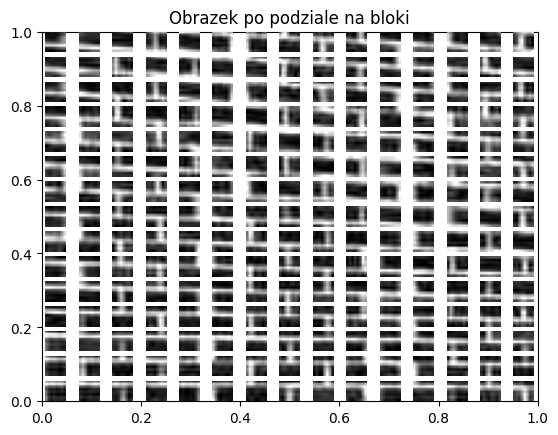

In [3]:
def load_image(path):
  raw_image = io.imread(path)
  gray_image = color.rgb2gray(raw_image)
  return gray_image

def crop_image(gray_image, crop_size):
  h, w = gray_image.shape
  new_h = (h // crop_size) * crop_size
  new_w = (w // crop_size) * crop_size
  cropped_image = gray_image[:new_h, :new_w]
  return cropped_image

def split_to_bloks(cropped_image, block_size):
  h, w = cropped_image.shape
  split_image = np.reshape(cropped_image, (h // block_size, block_size, w // block_size, block_size))
  split_image = np.transpose(split_image, (0, 2, 1, 3))
  return split_image

def show_blocks_grid(split_image):
  plt.title("Obrazek po podziale na bloki")
  for i in range(15):
    for j in range(15):
      plt.subplot(15, 15, i*15 + j + 1)
      plt.imshow(split_image[i, j], cmap = 'gray')
      plt.axis('off')
  plt.show()
  # plt.imshow(split_image[15, 0], cmap = 'gray')
  # print(type(split_image))
  # print(np.shape(split_image))

gray_image = load_image(path)
cropped_image = crop_image(gray_image, matrix_size)
split_image = split_to_bloks(cropped_image, matrix_size)
show_blocks_grid(split_image)

### Funkcje pomocnicze

#### **load_raw_image()**
1. Jako argument przyjmuje ścieżke do obrazu
2. Zwraca oryginalny obraz

#### **calculate_img_dimensions()**
1. Jako argument przyjmuje blok obrazu
2. Oblicza wysokość i szerokość bloku
#### **calculate_compression_mask()**
1. Jako argumenty przyjmuje liczbe kolumn i wierszy w bloku
2. Zwraca wymiary bloku w tablicy dwuelementowej

*Funkcje zostały dostosowane do obsługi bloków różnych wielkości*

#### **start_time_measure()**
1. Zapisuje czas wykonania
#### **end_time_measure(start)**
1. Jako argument przyjmuje czas wykonanai
2. Oblicza czas od rozpoczęcia pomiaru


In [4]:
def load_raw_image(path):
  raw_image = io.imread(path)
  return raw_image

def calculate_img_dimensions(img):
  img_h = np.shape(img)[0]
  img_w = np.shape(img)[1]
  return [img_h, img_w]

def calculate_compression_mask(M, N):
  mask_size = M // 2
  mask = np.zeros((M, N))
  for i in range (0, mask_size):
    for j in range(mask_size - i):
      mask[i, j] = 1
  return mask

def start_time_measure():
    start = timeit.default_timer()
    return start

def end_time_measure(start):
    end = timeit.default_timer()
    time_elapsed = end - start
    time_elapsed = (float(f'{time_elapsed:.4f}'))
    return time_elapsed

### Funkcje służące do wizualizacji wyników

In [5]:
def calculate_snr(cropped_image, combined_image):
  og = np.sum(cropped_image ** 2)
  dif = np.sum((cropped_image - combined_image) ** 2 )
  SNR = 10 * np.log10 (og/dif)
  return SNR

def calculate_noise(gray_image, combined_image):
  return gray_image - combined_image

def calculate_dct_coefficients(gray_image):
  FC = dct(dct(gray_image, axis = 0, norm='ortho'), axis=1, norm='ortho')
  return FC

def calculate_fft_coefficients(gray_image):
  FF = np.fft.fft2(gray_image)
  return FF

def caculate_aproximation_error(gray_image):
  FC = calculate_dct_coefficients(gray_image)
  FF = calculate_fft_coefficients(gray_image)
  sorted_dct = np.sort(np.abs(FC).flatten())[::-1]
  sorted_fft = np.sort(np.abs(FF).flatten())[::-1]
  total_energy_dct = np.sum(FC ** 2)
  total_energy_dft = np.sum(np.abs(FF) ** 2)
    
  errors_dct = []
  errors_fft = []
    
  M_max = len(sorted_dct)
  if M_max > 50000:
    M_max = 50000
    
  for m in range(1, M_max):
      energy_kept_dct = np.sum(sorted_dct[:m] ** 2)
      energy_kept_dft = np.sum(sorted_fft[:m] ** 2)
      errors_dct.append((total_energy_dct - energy_kept_dct) / total_energy_dct)
      errors_fft.append((total_energy_dft - energy_kept_dft) / total_energy_dft)
    
  return errors_dct, errors_fft

In [6]:
def total_time_chart(times):
    width = 0.2 
    
    type_label = ['Total time']
    time_means = {
        'DCT': np.sum(times[0]),
        'Scipy-DCT': np.sum(times[1]),
        'Numpy-FFT': np.sum(times[2])
    }
    
    x = np.arange(len(type_label))  
    fig, ax = plt.subplots(figsize=(6, 5)) 

    num_items = len(time_means)
    total_group_width = num_items * width
    start_pos = x - (total_group_width / 2) + (width / 2)

    for i, (attribute, measurement) in enumerate(time_means.items()):
        pos = start_pos + (i * width)
        rects = ax.bar(pos, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3, fmt='%.4f') 

    ax.set_ylabel('Execution time (s)')
    ax.set_title('Total execution time comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(type_label)
    ax.set_xlim(x[0] - 0.5, x[0] + 0.5) 
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

def show_decompression_efect(gray_image, dct_image, scipy_dct_image):
  plt.figure(figsize=(12, 6))
  plt.subplot(1, 3, 1)
  plt.title("Przed kompresją")
  plt.imshow(gray_image, cmap='gray')
  plt.subplot(1, 3, 2)
  plt.title("Po kompresji DCT")
  plt.imshow(dct_image, cmap ='gray')
  plt.subplot(1, 3, 3)
  plt.title("Po kompresji Scipy DCT")
  plt.imshow(scipy_dct_image, cmap='gray')
  plt.show()

def show_SNR(cropped_image, dct_image, scipy_dct_image, fft_image):
  plt.figure(figsize=(12, 6))
  SNR_dct = calculate_snr(cropped_image, dct_image)
  SNR_scipy_dct = calculate_snr(cropped_image, scipy_dct_image)
  SNR_numpy_fft = calculate_snr(cropped_image, fft_image)
  plt.subplot(1, 3, 1)
  plt.title(f"DCT\nSNR = {SNR_dct:.2f} dB")
  plt.imshow(dct_image, cmap='gray')
  plt.subplot(1, 3, 2)
  plt.title(f"Scipy DCT\nSNR = {SNR_scipy_dct:.2f} dB")
  plt.imshow(scipy_dct_image, cmap ='gray')
  plt.subplot(1, 3, 3)
  plt.title(f"Numpy FFT\nSNR = {SNR_numpy_fft:.2f} dB")
  plt.imshow(fft_image, cmap='gray')
  plt.show()

def show_correlation(cropped_image):
  errors_dct, errors_fft = caculate_aproximation_error(cropped_image)
  
  plt.title("Błąd aproksymacji")
  plt.plot(np.log10(errors_dct), color='red', label='DCT')
  plt.plot(np.log10(errors_fft), color='blue', label='Fourier')
  plt.xlabel("M - liczba zachowanych współczynników")
  plt.ylabel("log10(błąd)")
  plt.show()

def show_coeffcients(cropped_image):
  FC = calculate_dct_coefficients(cropped_image)
  FF = calculate_fft_coefficients(cropped_image)
  
  plt.figure(figsize=(12, 6))
  plt.subplot(1, 2, 1)
  plt.title("Scipy DCT")
  plt.imshow(np.log(1e-5 + np.abs(FC)), cmap='gray')
  plt.subplot(1, 2, 2)
  plt.title("Numpy FFT")
  plt.imshow(np.log(1e-5 + np.abs(FF)), cmap='gray')
  plt.show()

### Algorytm DCT from scratch (*wersja rozszerzona*)
#### **funkcja dct_compression()**
1. **Transormata 2-DCT-2D:** Podwójna transformata 2-DCT-1D zrealizowana z wykorzystaniem macierzy współczynników ($T$ oraz $T^T$).
2. **Kwantyzacja:** Realizowana za pomocą dynamicznej maski, obliczanej na podstawie wymiarów bloku.
3. **Odwrócenie transformaty**: Realizowane za pomocą funkcji przeciwnej do Transformaty 2-DCT-2D.
<p style='text-align: justify;'><i>Funkcja odpowiada za zamiane sposobu zapisu obrazka z bloków na częstotliwości ortogonalne oraz kwantyzację i odwrócenie transformacji, wzór oraz zasada działania funkcji zostały opisane poniżej. Kod został zoptymalizowany i przystosowany do obliczeń macierzowych z wykrozystaniem biblioteki numpy, ze względu na szybkość wykonywania operacji na macierzach w porównaniu do klasycznych zagnieżdżonych pętli.</i></p>


#### Równanie transformacji DCT (2D-DCT-2): 
$$B_{pq} = \sum_{m=0}^{M-1} \sum_{n=0}^{N-1} \alpha_p \alpha_q A_{mn} \cos \frac{\pi(2m + 1)p}{2M} \cos \frac{\pi(2n + 1)q}{2N} = \sum_{m=0}^{M-1} \sum_{n=0}^{N-1} A_{mn} \alpha_p \cos \frac{\pi(2m + 1)p}{2M} \alpha_q \cos \frac{\pi(2n + 1)q}{2N}, \quad \begin{matrix} 0 \le m \le M-1 \\ 0 \le n \le N-1 \end{matrix}$$
<br>

Dla obrazów, których blok jest macierzą kwadratową ($M = N$), transformację tę można zapisać w wydajnej formie macierzowej. Definiując macierz bazową $T$ jako:
$$T_{pm} = \alpha_p \cos \frac{\pi(2m + 1)p}{2M}$$

<br>
Otrzymujemy postać macierzową stosowaną w kodzie:
$$B = T \cdot A \cdot T^T$$

Współczynniki wagowe są zdefiniowane jako:
$$\alpha_p = \begin{cases} 1/\sqrt{M}, & p = 0 \\ \sqrt{2/M}, & 1 \le p \le M-1 \end{cases} \quad \alpha_q = \begin{cases} 1/\sqrt{N}, & q = 0 \\ \sqrt{2/N}, & 1 \le q \le N-1 \end{cases}$$
<br>

In [7]:
def dct_compression(split_image, img_h, img_w):
  img_block = split_image[img_h, img_w]
  M, N = calculate_img_dimensions(img_block)
  PI = np.pi

  m = np.arange(M)
  p = np.arange(M)
  m = np.reshape(m, (1, -1))
  p = np.reshape(p, (-1, 1))
  
  T = np.cos((PI * (2*m+1) * p) / (2*M))
  T[0, :] /= np.sqrt(M)         
  T[1:, :] /= np.sqrt(M / 2)
  B = (T @ img_block @ T.T)

  with np.printoptions(edgeitems=8, precision=1, linewidth=1000):
    if(img_h == 0 and img_w == 0):
      print(B)
  
  mask = calculate_compression_mask(M,N)
  B_masked = B * mask
  A_compressed = T.T @ B_masked @ T
  return A_compressed

#### **funkcja combine_dct_image()**
Funkcja odpowiada za ponowne połączenie bloków obrazu po wykonanej kompresji i dekompresji za pomocą funkcji **dct_compression()**. Celem funkcji jest przedstawienia poprawności działania algorytmów kompresji i dekompresji.


In [8]:
def combine_dct_image(split_image):
  img_h, img_w = calculate_img_dimensions(split_image)
  image_combined = np.zeros_like(split_image)
  for i in range(img_h):
    for j in range(img_w):
      image_block = dct_compression(split_image, i, j)
      image_combined [i, j] = image_block
  return image_combined 

### Algorytm DCT z wykorzystaniem biblioteki Scipy (*wersja podstawowa*)
#### **scipy_dct()**
Jest to algorytm **2-DCT-2D** zaimplementowany z wykorzystaniem gotowego rozwiązania z biblioteki Scipy. Kluczową różnicą między tym algorytmem, a algorytmem *"from scratch"* jest obsługa macierzy bloków o różnych wymiarach $h \neq w$.


In [9]:
def scipy_dct(split_image, img_h, img_w):
 with np.printoptions(edgeitems = 8, precision = 2, linewidth = 1000):
  B = dct(dct(split_image, axis=0, norm='ortho'), axis=1, norm='ortho')
  with np.printoptions(edgeitems=8, precision=1, linewidth=1000):
    if(img_h == 0 and img_w == 0):
      print(B)
  M, N = calculate_img_dimensions(split_image)
  mask = calculate_compression_mask(M, N)
  B_compressed = B * mask
  A_compressed = idct(idct(B_compressed, axis=0, norm='ortho'), axis=1, norm='ortho')
  return A_compressed

#### **combine_scipy_dct_image()**
Funkcja jest odpowiednikiem funkcji **combine_dct_image** i została dostosowana do obsługi macierzy o różnych wymiarach.


In [10]:
def combine_scipy_dct_image(split_image):
  img_h, img_w = calculate_img_dimensions(split_image)
  image_combined = np.zeros_like(split_image)
  for i in range(img_h):
    for j in range(img_w):
      image_block = scipy_dct(split_image[i,j], i, j)
      image_combined[i, j] = image_block
  return image_combined

#### **reshape_combined_image()**
Funkcja służy "złożenia" pełnego obrazu z pojedynczych bloków dla algorytmów DCT.


In [11]:
def reshape_combined_image(image_combined, block_size):
  h, w = calculate_img_dimensions(image_combined)
  temp = image_combined.transpose(0, 2, 1, 3)
  image_combined = np.reshape(temp, (h * block_size, w * block_size))
  return image_combined

### Algorytm FFT z wykorzystaniem biblioteki Numpy
Jest to algorytm 2D-DFT zaimplementowany z wykorzystaniem szybkiej transformaty Fouriera (FFT) z biblioteki Numpy. Kluczową cechą tej implementacji jest wykorzystanie progowania amplitudowego ($M$), które pozwala na selektywne usuwanie słabszych składowych częstotliwościowych bezpośrednio w dziedzinie liczb zespolonych.

In [12]:
def numpy_fft(cropped_image, M):
  Transformation = np.fft.fft2(cropped_image)
  mask = np.abs(Transformation) >= M
  Transformation_compressed = Transformation * mask
  fft_image = np.real(np.fft.ifft2(Transformation_compressed))
  return fft_image

#### Porównanie współczy współczynników $B_{p,q}$ algorytmów DCT i Scipy DCT
1. **Współczynniki DC** ($p,q=0$) Reprezentuje średnią jasność całego bloku pikseli. Jest to "najważniejsza" wartość, ponieważ niesie najwięcej informacji o ogólnym kolorze fragmentu obrazu.
3. **Wpółczynnik AC** ($p,q>0$) - Reprezentują amplitudy poszczególnych bazowych funkcji kosinusoidalnych o różnych częstotliwościach. Im wyższe indeksy $p, q$, tym wyższa częstotliwość zmian (*detali*) w poziomie i pionie.


In [13]:
times = np.zeros((3,1))
start = start_time_measure()
image_compressed_dct = combine_dct_image(split_image)
time = end_time_measure(start)
times[0]=time

[[ 4.1e+00 -1.9e-01  1.1e-01 -2.1e-02 -2.2e-04  1.9e-03 -5.2e-04  6.9e-04]
 [-1.9e-01 -4.2e-02  4.6e-02 -3.2e-02 -5.5e-04  5.7e-04 -1.1e-03 -8.2e-04]
 [-3.1e-01  2.9e-02 -4.4e-02 -1.4e-03 -3.0e-03 -7.3e-04 -1.0e-03 -1.6e-03]
 [ 3.4e-01  5.5e-02 -3.5e-02  2.6e-04 -1.2e-03  6.7e-04  5.4e-04 -1.5e-03]
 [-1.7e-01  3.6e-02  6.4e-04  9.1e-04 -1.5e-03 -8.4e-04 -2.8e-03 -3.4e-04]
 [-4.2e-02 -5.7e-02 -3.3e-04  7.0e-04 -3.0e-03 -9.9e-05  5.9e-04  2.2e-03]
 [ 1.5e-01  2.2e-03 -3.8e-04 -1.0e-03 -2.6e-03 -1.2e-03  5.0e-04 -9.5e-04]
 [-1.1e-01 -1.4e-03 -5.5e-04  4.4e-04 -3.8e-03 -1.4e-03  1.7e-04  3.0e-03]]


In [14]:
start = start_time_measure()
image_compressed_scipy_dct = combine_scipy_dct_image(split_image)
time = end_time_measure(start)
times[1]=time

[[ 4.1e+00 -1.9e-01  1.1e-01 -2.1e-02 -2.2e-04  1.9e-03 -5.2e-04  6.9e-04]
 [-1.9e-01 -4.2e-02  4.6e-02 -3.2e-02 -5.5e-04  5.7e-04 -1.1e-03 -8.2e-04]
 [-3.1e-01  2.9e-02 -4.4e-02 -1.4e-03 -3.0e-03 -7.3e-04 -1.0e-03 -1.6e-03]
 [ 3.4e-01  5.5e-02 -3.5e-02  2.6e-04 -1.2e-03  6.7e-04  5.4e-04 -1.5e-03]
 [-1.7e-01  3.6e-02  6.4e-04  9.1e-04 -1.5e-03 -8.4e-04 -2.8e-03 -3.4e-04]
 [-4.2e-02 -5.7e-02 -3.3e-04  7.0e-04 -3.0e-03 -9.9e-05  5.9e-04  2.2e-03]
 [ 1.5e-01  2.2e-03 -3.8e-04 -1.0e-03 -2.6e-03 -1.2e-03  5.0e-04 -9.5e-04]
 [-1.1e-01 -1.4e-03 -5.5e-04  4.4e-04 -3.8e-03 -1.4e-03  1.7e-04  3.0e-03]]


In [15]:
start = start_time_measure()
fft_image = numpy_fft(cropped_image, 50)
time = end_time_measure(start)
times[2] = time

### Porównanie czasu wykonywania kompresji

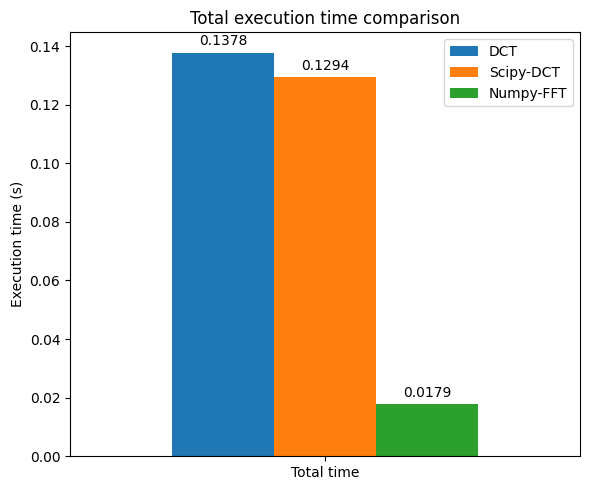

In [16]:
total_time_chart(times)

### Wizualizacja zmian w obrazie

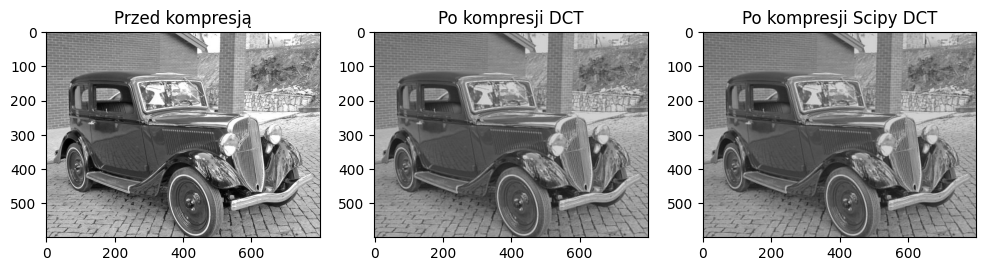

In [17]:
dct_image = reshape_combined_image(image_compressed_dct, matrix_size)
scipy_dct_image = reshape_combined_image(image_compressed_scipy_dct, matrix_size)
show_decompression_efect(gray_image, dct_image, scipy_dct_image)

SNR (Signal-to-Noise Ratio) jest miarą jakości skompresowanego obrazu względem oryginału. Obliczana jest według wzoru:
$$SNR = 10 \cdot \log_{10}\left(\frac{\sum f(x,y)^2}{\sum (f(x,y) - \hat{f}(x,y))^2}\right)$$

f(x,y) to obraz oryginalny, a f^(x,y)\hat{f}(x,y)
f^​(x,y) to obraz po kompresji i rekonstrukcji. Licznik to energia sygnału oryginalnego, mianownik to energia błędu (różnicy między oryginałem a rekonstrukcją). Wynik wyrażany jest w decybelach (dB).

Im wyższa wartość SNR tym obraz jest bliższy oryginałowi — kompresja jest mniej stratna. Im bliżej zera tym obraz bardziej odbiega od oryginału — większa utrata informacji.

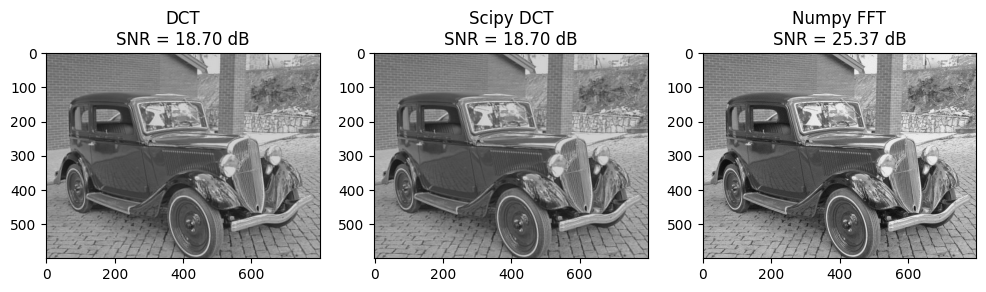

In [18]:
show_SNR(cropped_image, dct_image, scipy_dct_image, fft_image)

Funkcja show_correlation prezentuje wykres błędu aproksymacji w skali logarytmicznej dla dwóch transformacji — DCT i FFT. Błąd aproksymacji ϵ(M)2\epsilon(M)^2
ϵ(M)2 określa jak bardzo zrekonstruowany obraz odbiega od oryginału w zależności od liczby zachowanych współczynników M. Im więcej współczynników zachowujemy tym mniejszy błąd. Wykres pozwala porównać efektywność obu transformacji — im szybciej krzywa opada tym lepsza baza dla kompresji danego obrazu.

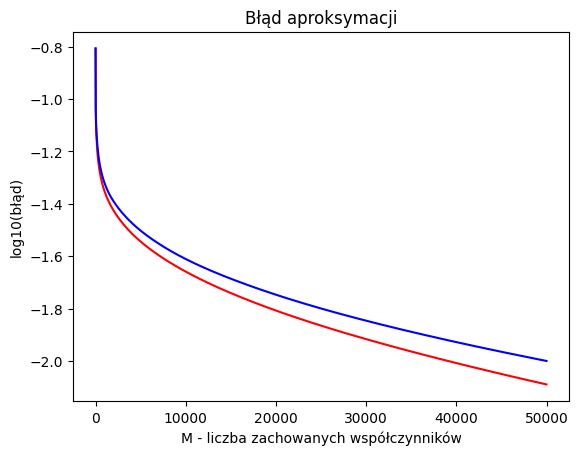

In [19]:
show_correlation(cropped_image)

Współczynniki dodać opis

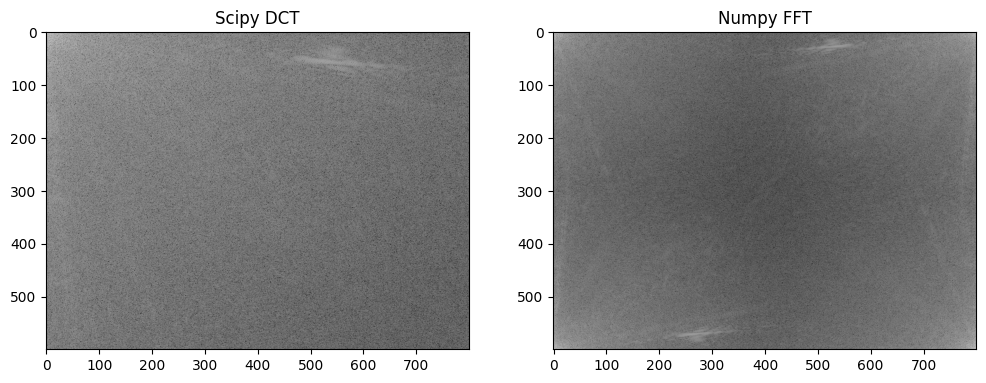

In [20]:
show_coeffcients(cropped_image)

## CwELpeg (Compressed with Elegance Lite)
Wersja DCT algorytmu przystosowana do kompresji i zapisu obrazu, a także jego odwzorowania na podstawie nagłówka, który zawiera wymiary obrazu i wielkość bloku.

In [21]:
def dct_compress_image(split_image, img_h, img_w):
  img_block = split_image[img_h, img_w]
  M, N = calculate_img_dimensions(img_block)
  PI = np.pi

  m = np.arange(M)
  p = np.arange(M)
  m = np.reshape(m, (1, -1))
  p = np.reshape(p, (-1, 1))
  
  T = np.cos((PI * (2*m+1) * p) / (2*M))
  T[0, :] /= np.sqrt(M)         
  T[1:, :] /= np.sqrt(M / 2)
  B = (T @ img_block @ T.T)

  mask = calculate_compression_mask(M,M)
  B_masked = B * mask

  return B_masked

def transform_B_into_row(B_masked):
  B_masked = B_masked[B_masked != 0]
  return B_masked
  
def compress_B(split_image):
    img_h, img_w, M, N = np.shape(split_image)
    all_data = [] 
    
    all_data.extend([img_h])
    all_data.extend([img_w])
    all_data.extend([M])

    for i in range(img_h):
        for j in range(img_w):
          B_masked = dct_compress_image(split_image, i, j)
          compressed_values = transform_B_into_row(B_masked)
          all_data.extend(compressed_values)
    
    final_data = np.array(all_data, dtype=np.float16)
    final_data2 = np.round(final_data, 2)
    np.savez_compressed('kompresja.cwelpeg.npz', data=final_data2)

def decompress_B(filename):
    archive = np.load(filename)
    final_data = archive['data']
    img_h, img_w, M = int(final_data[0]), int(final_data[1]), int(final_data[2])
    final_data = np.delete(final_data, 0, 0)
    final_data = np.delete(final_data, 0, 0)
    final_data = np.delete(final_data, 0, 0)
    mask_size = M // 2
    count_per_block = 0
    for i in range(mask_size):
        for j in range(mask_size - i):
            count_per_block += 1
            
    full_image = np.zeros((img_h * M, img_w * M)) 
    
    PI = np.pi
    m = np.arange(M).reshape(1, -1)
    p = np.arange(M).reshape(-1, 1)
    T = np.cos((PI * (2*m+1) * p) / (2*M))
    T[0, :] /= np.sqrt(M)
    T[1:, :] /= np.sqrt(M / 2)
    
    ptr = 0
    for i in range(img_h):
        for j in range(img_w):
            block_flat = final_data[ptr : ptr + count_per_block]
            ptr += count_per_block
            
            B_reconstructed = np.zeros((M, M))
            v_idx = 0
            for row in range(mask_size):
                for col in range(mask_size - row):
                    if v_idx < len(block_flat):
                        B_reconstructed[row, col] = block_flat[v_idx]
                        v_idx += 1
            
            img_block = T.T @ B_reconstructed @ T
            full_image[i*M : (i+1)*M, j*M : (j+1)*M] = img_block
    return full_image

def compress_image_to_file(split_image):
    compress_B(split_image)
    full_image = decompress_B('kompresja.cwelpeg.npz')
    plt.imshow(full_image, cmap='gray')
    plt.title("CwELpeg")
    plt.axis('off')
    plt.show()

### Obraz po dekompresji

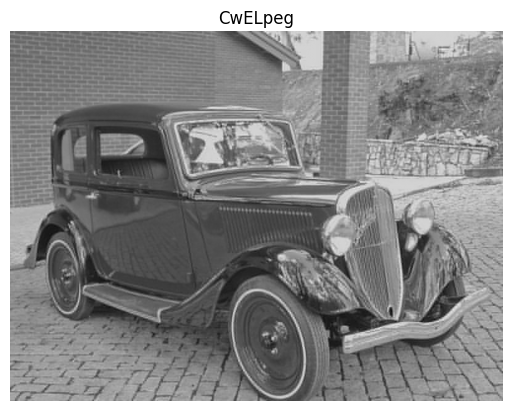

In [22]:
compress_image_to_file(split_image)